In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nsl-kdd/KDDTrain+.txt')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nsl-kdd/KDDTest+.txt')
print(train.shape)
test.shape

(125972, 43)


(22543, 43)

In [ ]:
# changing column names to meaningful names to understand data properly
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

train.columns = columns
test.columns = columns

In [ ]:
df = pd.concat([train, test], ignore_index=True)
df.shape

(148515, 43)

In [ ]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
df['attack'].unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl', 'saint', 'mscan', 'apache2',
       'snmpgetattack', 'processtable', 'httptunnel', 'ps', 'snmpguess',
       'mailbomb', 'named', 'sendmail', 'xterm', 'worm', 'xlock',
       'xsnoop', 'sqlattack', 'udpstorm'], dtype=object)

In [ ]:
# lists to hold our attack classifications
dos_attacks = ['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm']
probe_attacks = ['ipsweep','mscan','nmap','portsweep','saint','satan']
privilege_attacks = ['buffer_overflow','loadmdoule','perl','ps','rootkit','sqlattack','xterm']
access_attacks = ['ftp_write','guess_passwd','http_tunnel','imap','multihop','named','phf','sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster','xclock','xsnoop']

# we will use these for plotting below
attack_labels = ['Normal','DoS','Probe','Privilege','Access']

# helper function to pass to data frame mapping
def map_attack(attack):
    if attack in dos_attacks:
        attack_type = 'dos'
    elif attack in probe_attacks:
        attack_type = 'probe'
    elif attack in privilege_attacks:
        attack_type = 'privilege'
    elif attack in access_attacks:
        attack_type = 'remote_access'
    else:
        attack_type = 'normal'

    return attack_type

# map the data and join to the data set
attack_map = df.attack.apply(map_attack)
df['attack_map'] = attack_map

# view the result
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,attack_map
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19,dos
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21,dos


In [ ]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack', 'level', 'attack_map'],
      dtype='object')

In [ ]:
df.drop('attack', axis=1, inplace=True)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level,attack_map
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,15,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,19,dos
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,21,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,21,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,21,dos


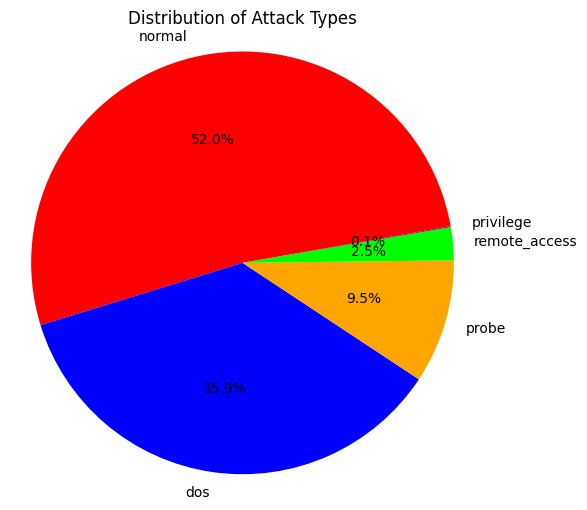

In [ ]:
# list of CSS color names
css_colors = ["red", "blue", "orange", "lime", "purple"]
attack_counts = df['attack_map'].value_counts()

# Create the pie chart with CSS colors
plt.figure(figsize=(6, 6))
plt.pie(
    attack_counts,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=10,
    colors=css_colors
)
plt.title('Distribution of Attack Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [ ]:
df_orig = df.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for i in df.columns:
    if (df[i].dtypes== 'object') :
        df[i] = le.fit_transform(df[i])


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to store the original values
df_original = df.copy()

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        # Store the original values for the column
        df_original[column + '_original'] = df[column]

        # Apply label encoding
        df[column] = le.fit_transform(df[column])

        # Display the before and after values
        print(f"Column: {column}")
        print("Before Label Encoding:")
        print(df_original[column + '_original'].unique())
        print("After Label Encoding:")
        print(df[column].unique())
        print("-" * 20)

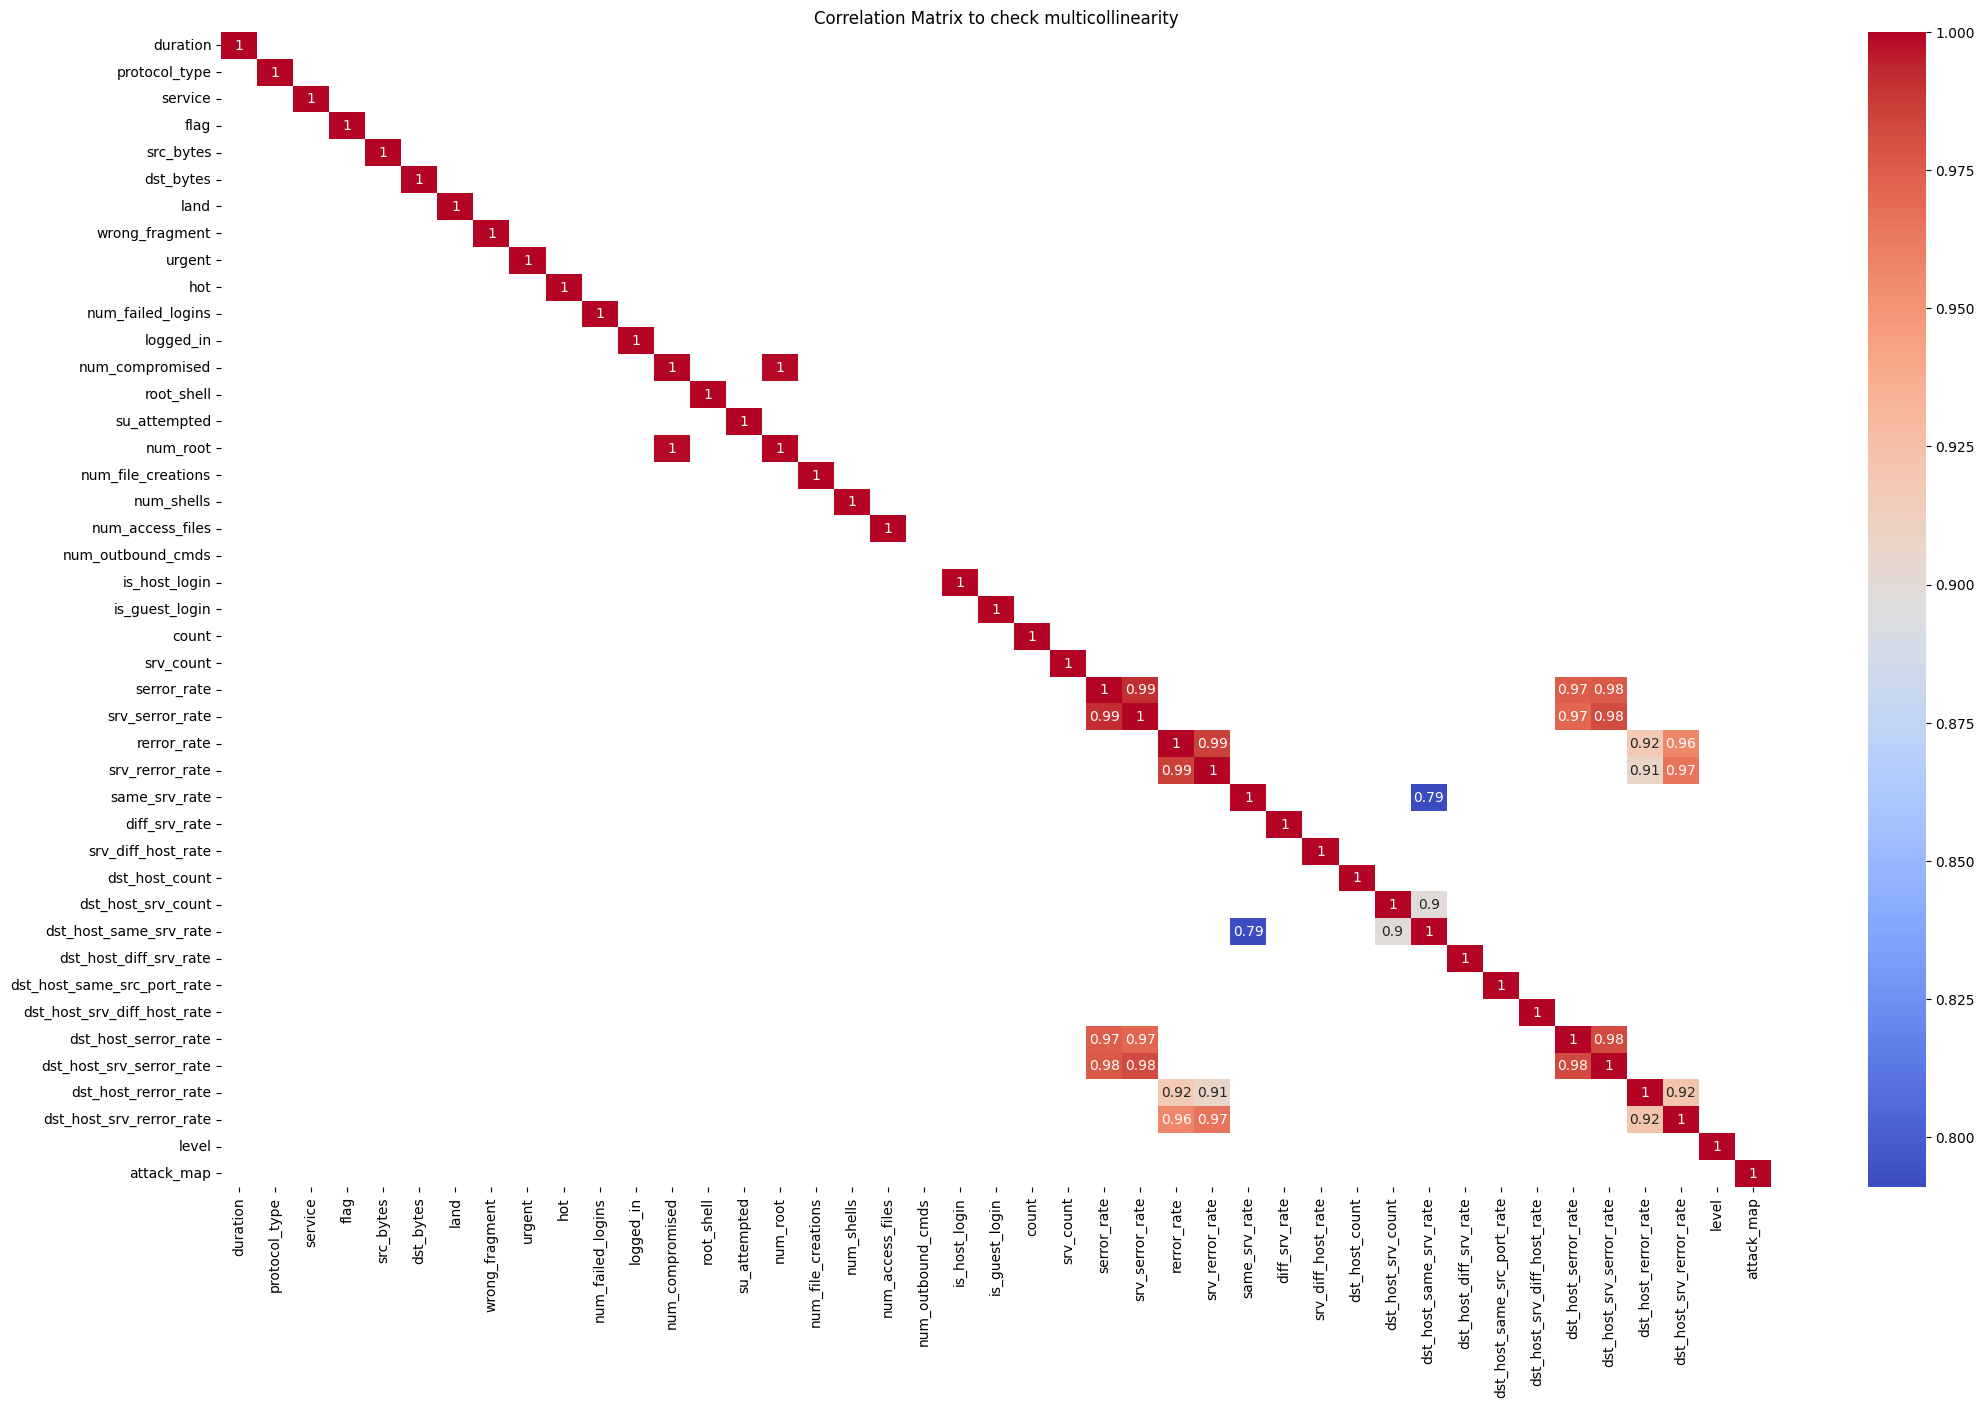

In [ ]:
import seaborn as sns
corr_matrix = df.corr()
high_corr = corr_matrix[(corr_matrix > 0.75) & (corr_matrix <= 1.0)]
plt.figure(figsize=(25,15))
sns.heatmap(high_corr, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix to check multicollinearity')
plt.show()

'is_guest_login'  ***holds***  'hot'  

'num_root'  ***holds***  'num_compromised'

'serror_rate'  ***holds***  'srv_serror_rate' , 'dst_host_serror_rate' and 'dst_host_srv_serror_rate'

'rerror_rate'  ***holds***  'srv_rerror_rate','dst_host_rerror_rate', 'dst_host_srv_rerror_rate'

'dst_host_srv_serror_rate'  ***holds***  'same_srv_rate' and 'dst_host_srv_count'

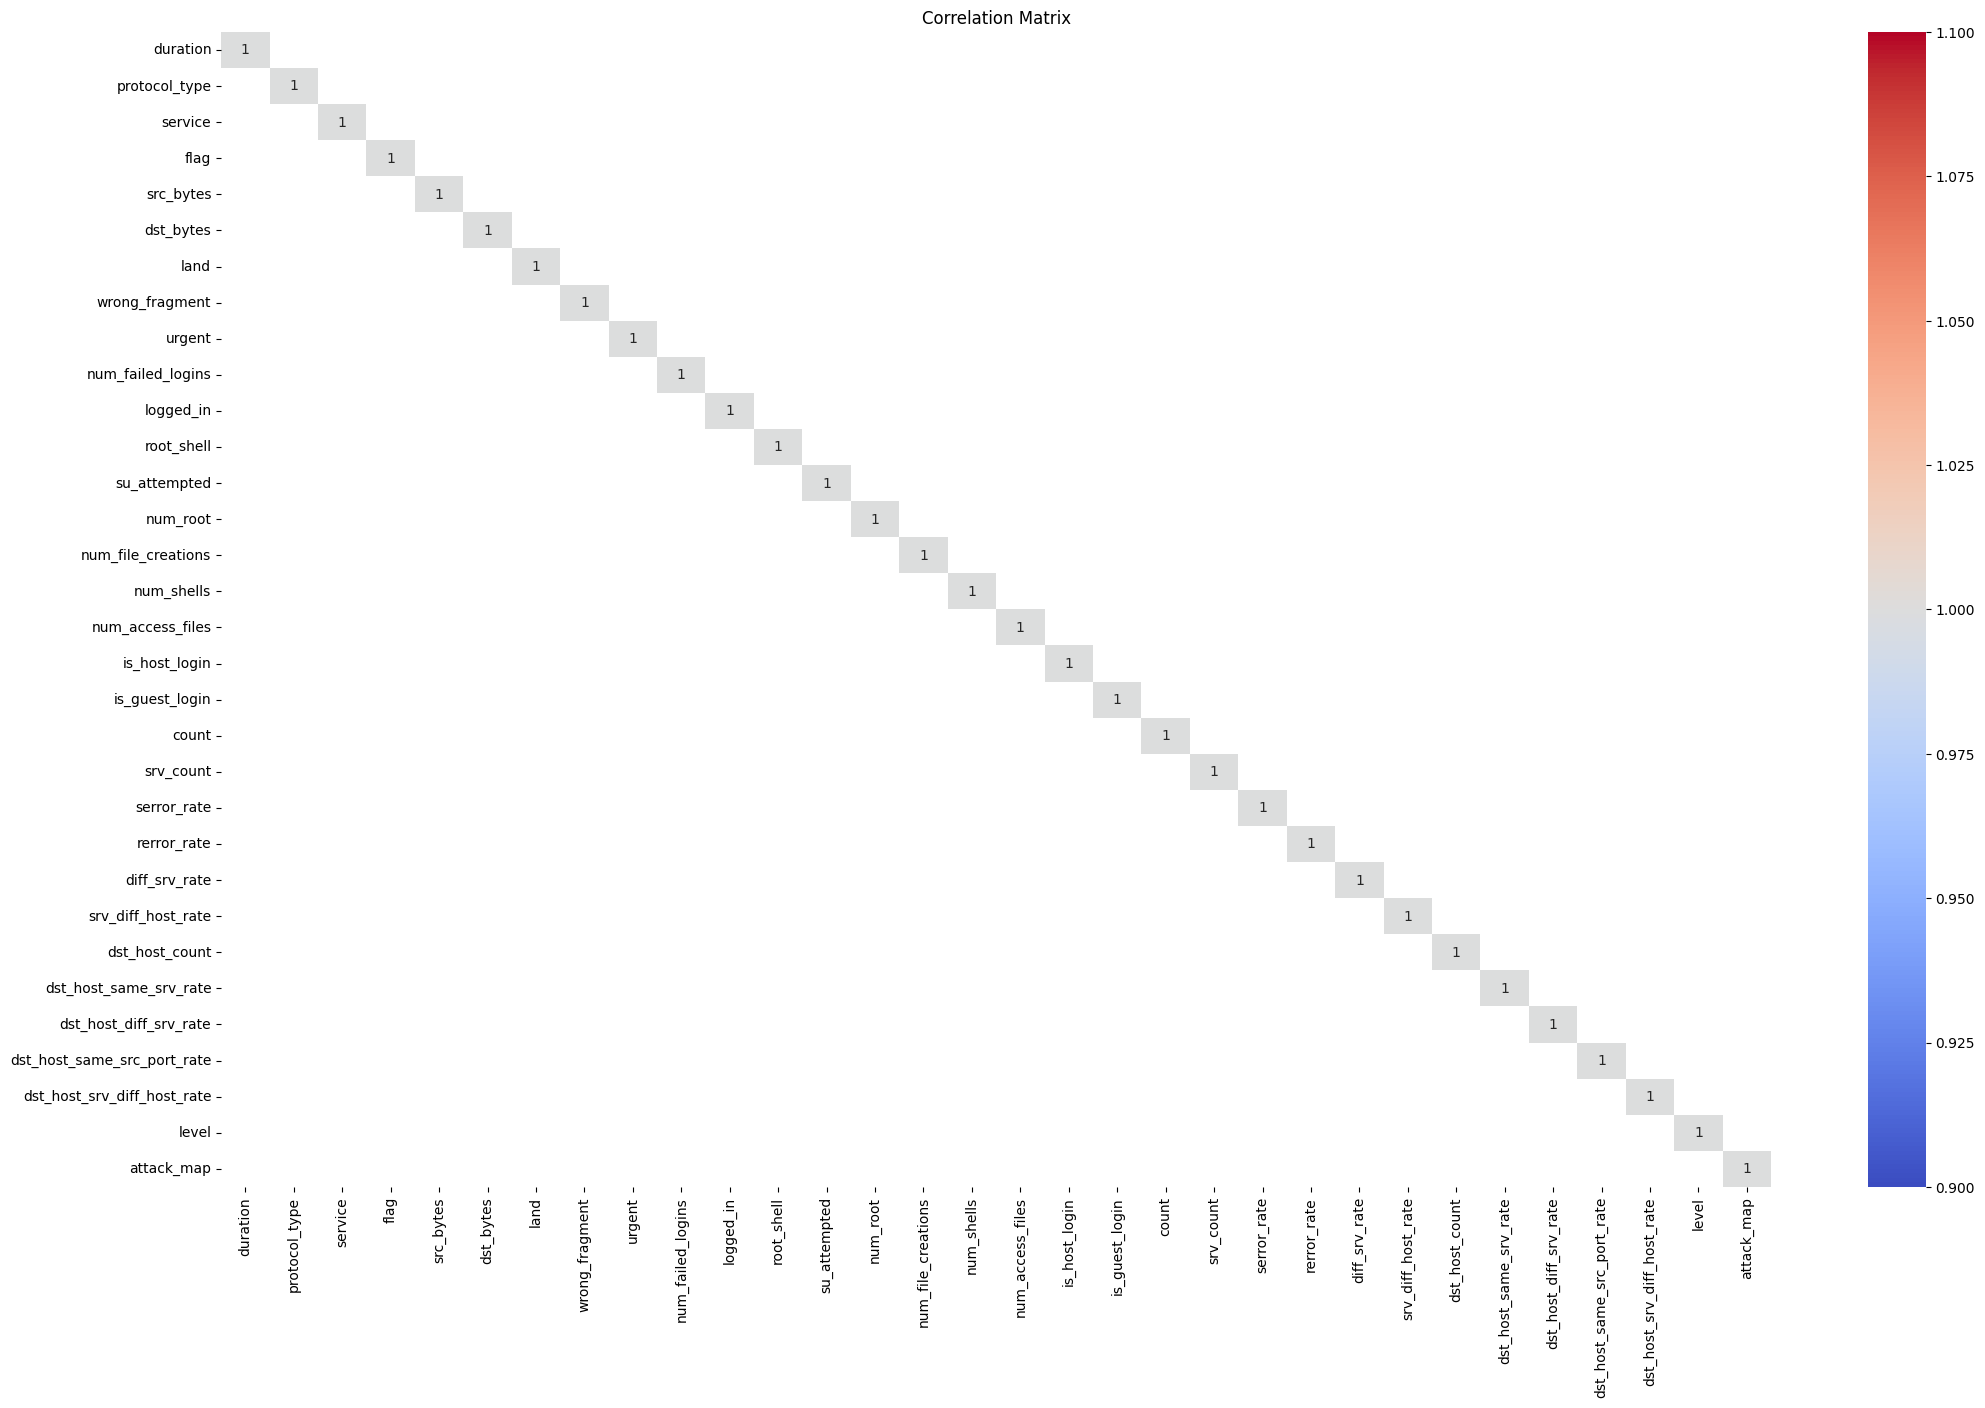

In [ ]:
df_new_extracted =df.drop(['num_outbound_cmds','hot','num_compromised','srv_serror_rate','dst_host_serror_rate','dst_host_srv_serror_rate', 'srv_rerror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','same_srv_rate','dst_host_srv_count'], axis=1, inplace=False)

import seaborn as sns
corr_matrix1 = df_new_extracted.corr()
high_corr1 = corr_matrix1[(corr_matrix1 > 0.75) & (corr_matrix1 <= 1.0)]
plt.figure(figsize=(25,15))
sns.heatmap(high_corr1, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()


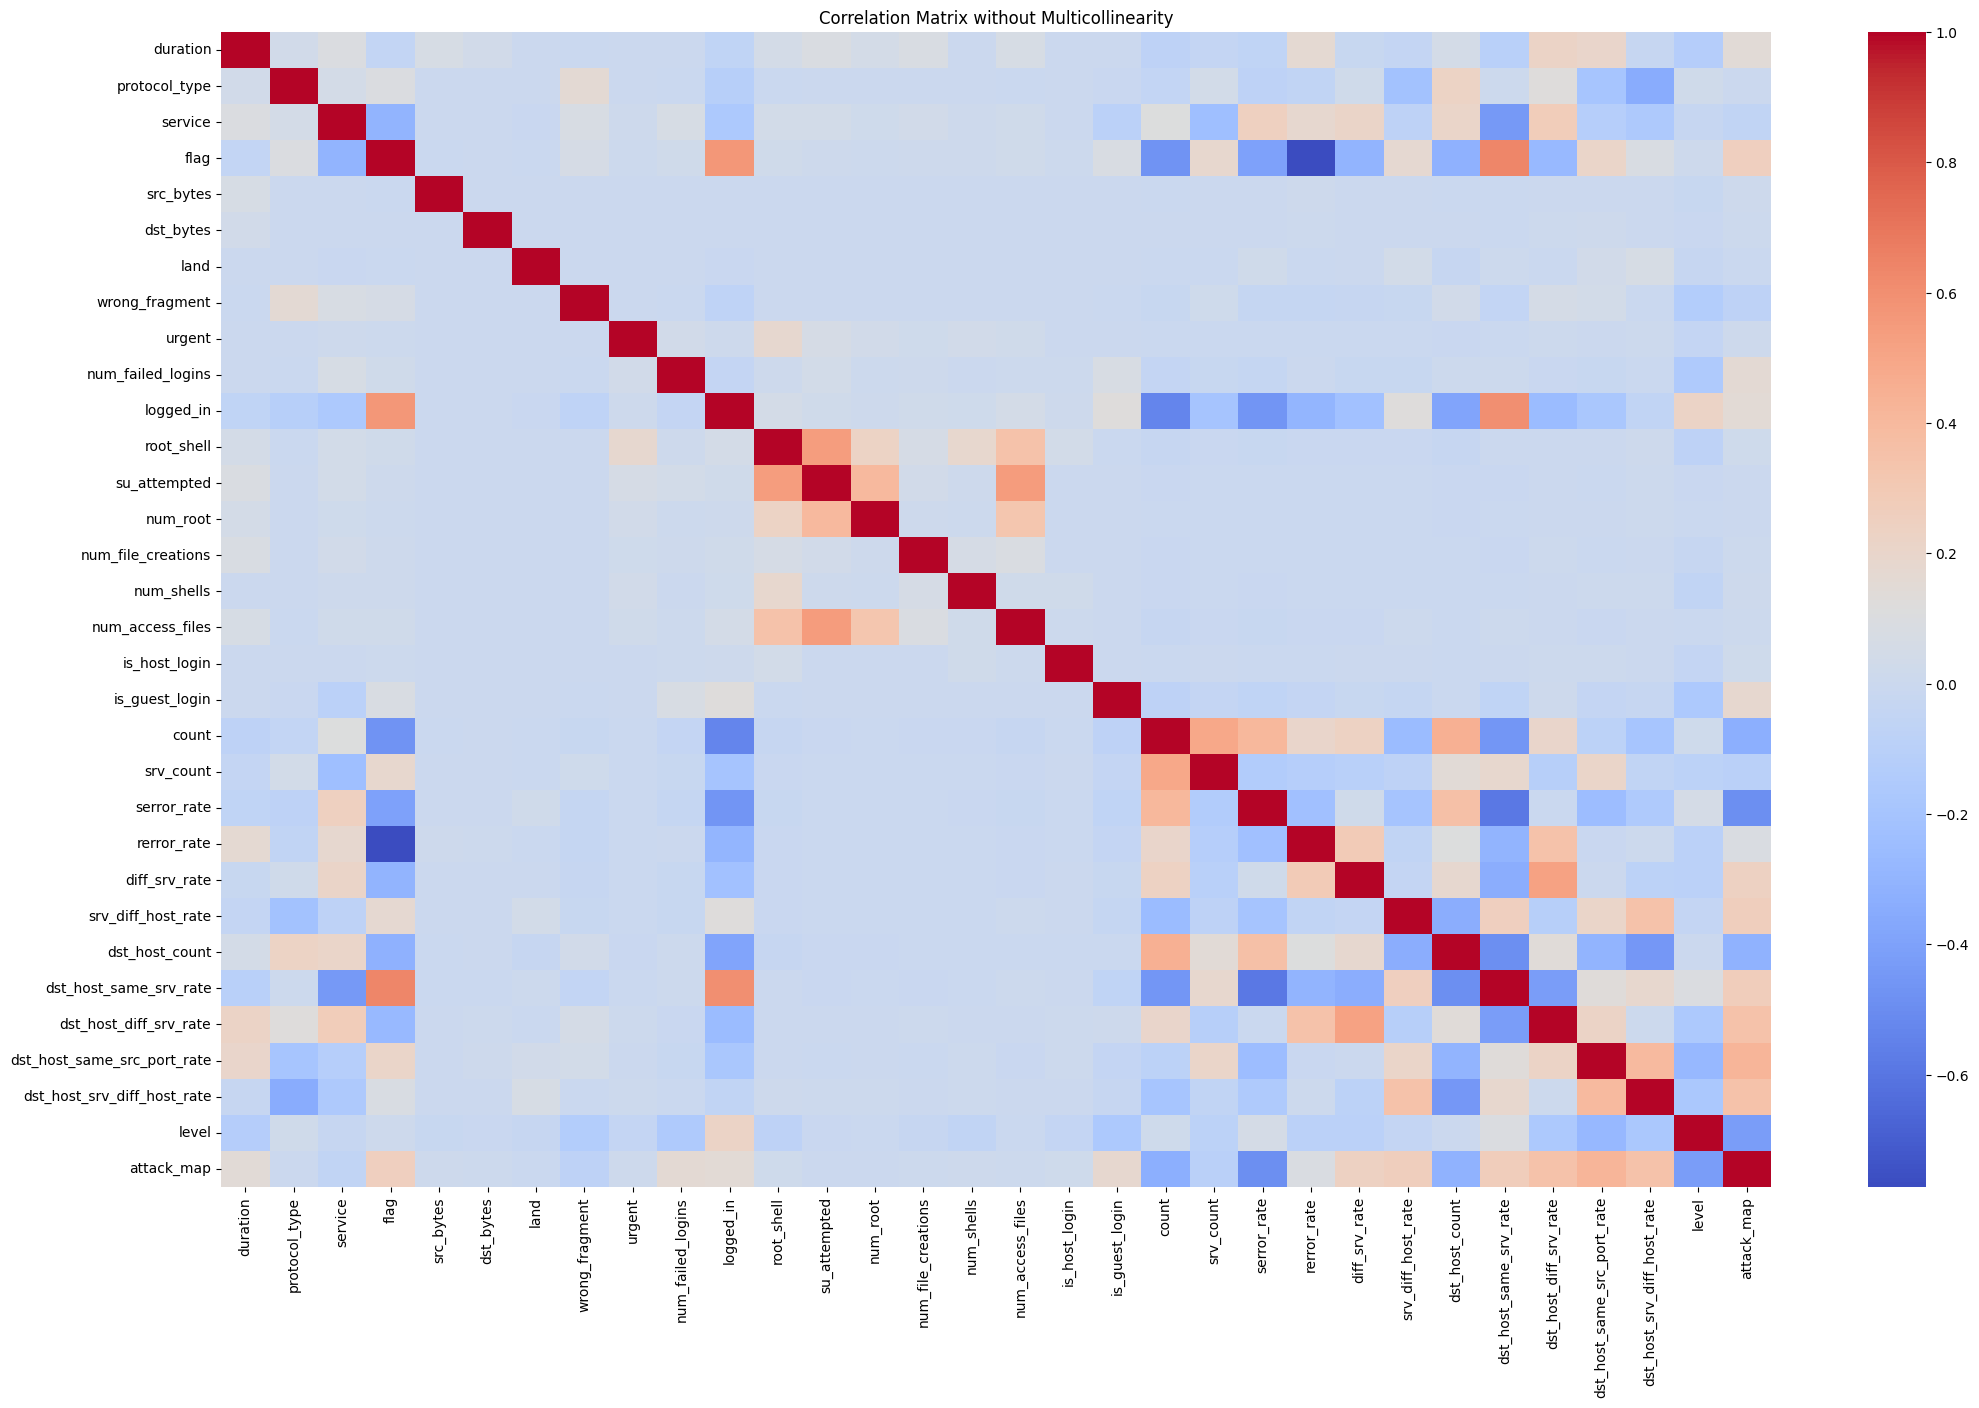

In [ ]:
plt.figure(figsize=(25,15))
sns.heatmap(corr_matrix1, cmap='coolwarm')
plt.title('Correlation Matrix without Multicollinearity')
plt.show()

In [ ]:
features_extracted  = df_new_extracted.columns
df_orig = df_orig[features_extracted]
df_orig.shape

(148515, 32)

In [ ]:
df_orig.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,num_failed_logins,...,rerror_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,level,attack_map
0,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.15,0.00,255,0.00,0.60,0.88,0.00,15,normal
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.0,0.07,0.00,255,0.10,0.05,0.00,0.00,19,dos
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.0,0.00,0.00,30,1.00,0.00,0.03,0.04,21,normal
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.00,0.09,255,1.00,0.00,0.00,0.00,21,normal
4,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.06,0.00,255,0.07,0.07,0.00,0.00,21,dos


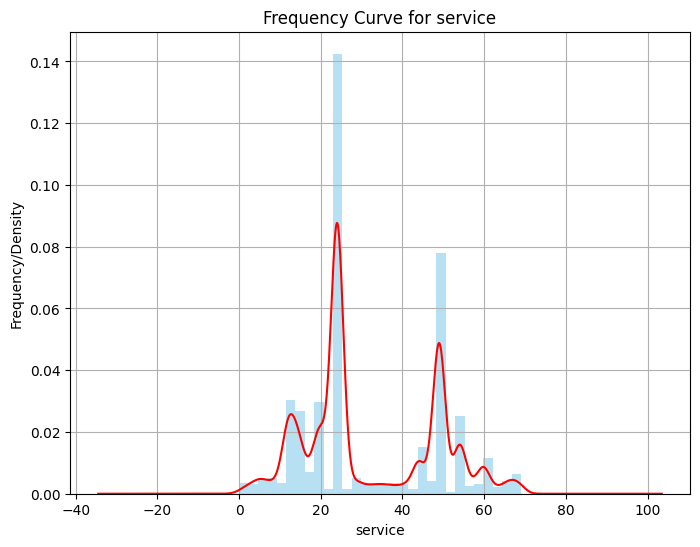

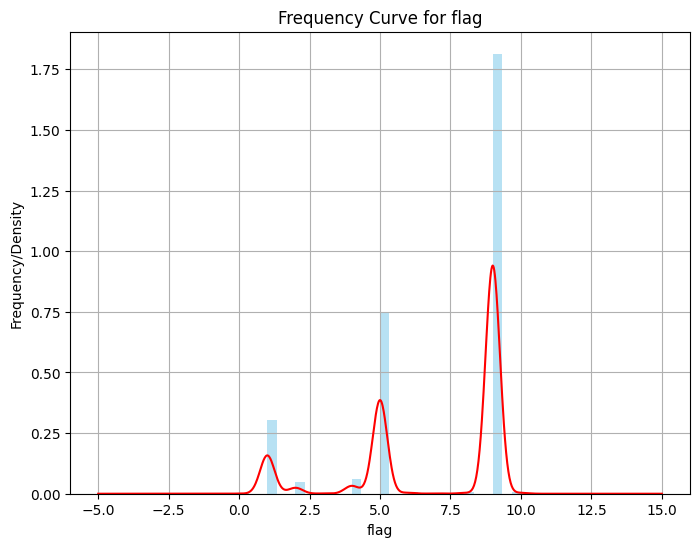

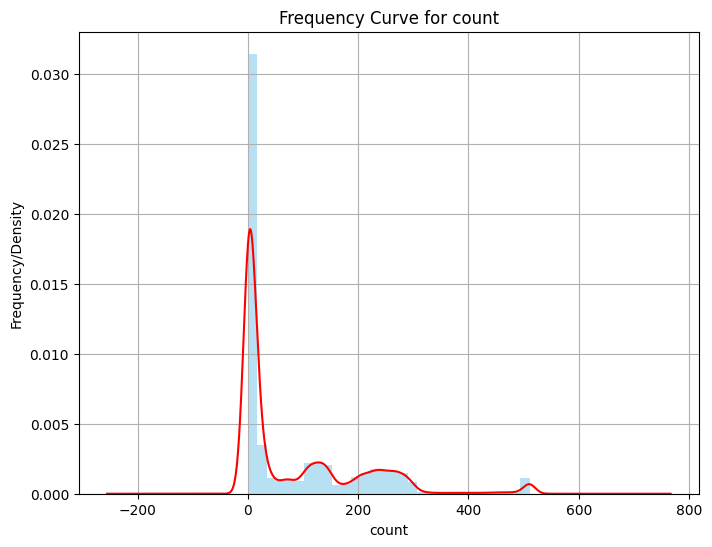

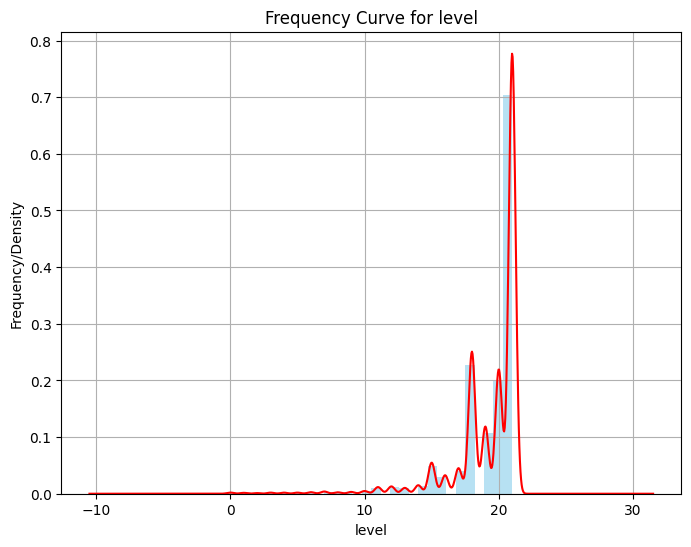

In [ ]:
for feature in df_new_extracted[['service', 'flag', 'count', 'level']]:
    plt.figure(figsize=(8, 6))
    df_new_extracted[feature].plot(kind='hist', bins=30, density=True, alpha=0.6, color='skyblue')  # Adjust bins as needed
    df_new_extracted[feature].plot(kind='kde', color='red')  # Overlay KDE
    plt.title(f'Frequency Curve for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency/Density')
    plt.grid(True)
    plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Separate features and target variable
X = df.drop('attack_map', axis=1)
y = df['attack_map']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


<Figure size 1000x600 with 0 Axes>

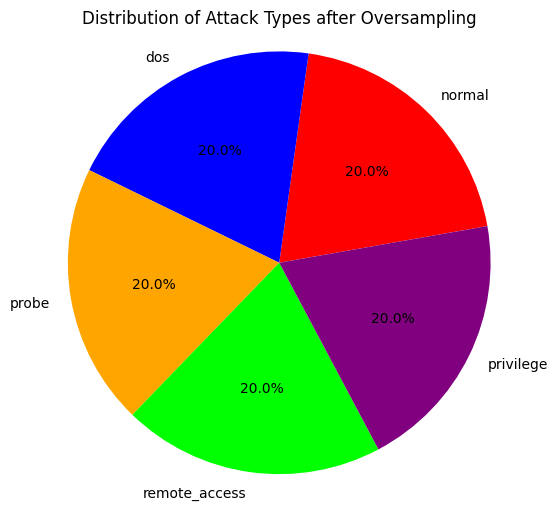

In [ ]:
# Create a mapping for attack types
attack_mapping = {
    0: 'normal',
    1: 'dos',
    2: 'probe',
    3: 'privilege',
    4: 'remote_access'
}

# Map the numerical attack labels back to string labels
y_resampled_str = y_resampled.map(attack_mapping)

plt.figure(figsize=(10, 6))
attack_count = y_resampled_str.value_counts()


# list of CSS color names
css_colors = ["red", "blue", "orange", "lime", "purple"]

# Create the pie chart with CSS colors
plt.figure(figsize=(6, 6))
plt.pie(
    attack_count,
    labels=attack_counts.index,
    autopct='%1.1f%%',
    startangle=10,
    colors=css_colors
)
plt.title('Distribution of Attack Types after Oversampling')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
print(X_resampled.shape)
print(y_resampled.shape)

(386030, 42)
(386030,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_, y_train, y_ = train_test_split(X_resampled, y_resampled, stratify=y_resampled ,test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_, y_, stratify=y_, test_size=0.4, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(270221, 42)
(46324, 42)
(69485, 42)
(270221,)
(46324,)
(69485,)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report

#1. ANN
model_ann = Sequential()
model_ann.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model_ann.add(Dense(32, activation='relu'))
model_ann.add(Dense(5, activation='softmax'))
model_ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1= model_ann.fit(X_train_scaled, y_train, epochs=20, validation_data=(X_val_scaled, y_val), batch_size=32, verbose=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9462 - loss: 0.1730 - val_accuracy: 0.9871 - val_loss: 0.0413
Epoch 2/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9876 - loss: 0.0378 - val_accuracy: 0.9895 - val_loss: 0.0311
Epoch 3/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.9902 - loss: 0.0299 - val_accuracy: 0.9896 - val_loss: 0.0339
Epoch 4/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9912 - loss: 0.0259 - val_accuracy: 0.9903 - val_loss: 0.0269
Epoch 5/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9920 - loss: 0.0231 - val_accuracy: 0.9900 - val_loss: 0.0271
Epoch 6/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step - accuracy: 0.9930 - loss: 0.0208 - val_accuracy: 0.9931 - val_loss: 0.0214
Epoch 7/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.9935 - loss: 0.0194 - val_accuracy: 0.9934 - val_loss: 0.0211
Epoch 8/20
8445/8445 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9939 - loss: 0

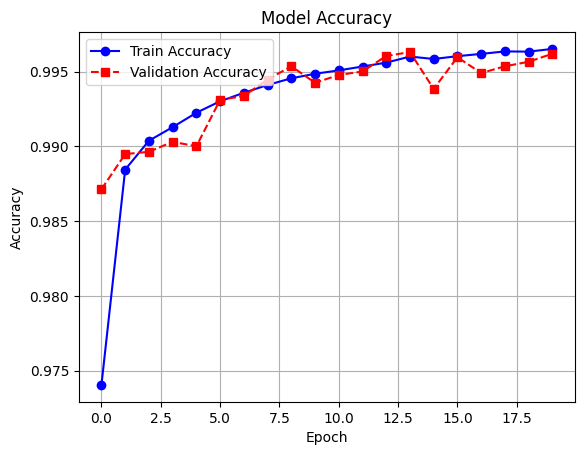

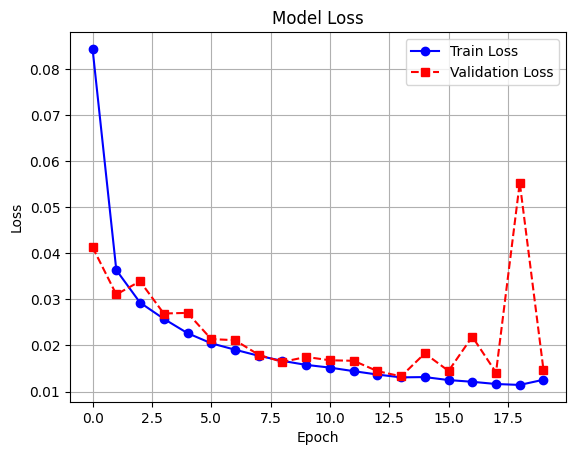

Validation Loss: 0.0147
Validation Accuracy: 99.62%


In [ ]:
# Plot training & validation accuracy values
plt.plot(history1.history['accuracy'], color='blue', linestyle='-', marker='o', label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], color='red', linestyle='--', marker='s', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.plot(history1.history['loss'], color='blue', linestyle='-', marker='o', label='Train Loss')
plt.plot(history1.history['val_loss'], color='red', linestyle='--', marker='s', label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Evaluate the model and print the accuracy
loss, accuracy = model_ann.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")


In [ ]:
# Predict the classes for the test set
y_pred = model_ann.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# Evaluate the model on the test set
loss, accuracy = model_ann.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


2172/2172 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Test Loss: 0.0149
Test Accuracy: 99.65%


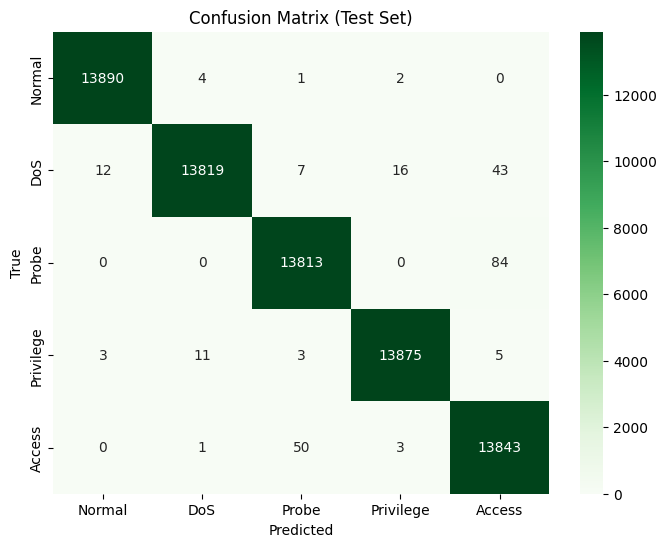

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal','DoS','Probe','Privilege','Access'],
            yticklabels=['Normal','DoS','Probe','Privilege','Access'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()